In [ ]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentences = [
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket match by 5 wickets",
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements of ingredients",
    "The recipe includes fresh vegetables and spices",
    "Strong passwords help protect user accounts",
    "Cyber attacks can compromise sensitive data",
    "Encryption ensures secure communication over networks",
    "Firewalls prevent unauthorized access to systems"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


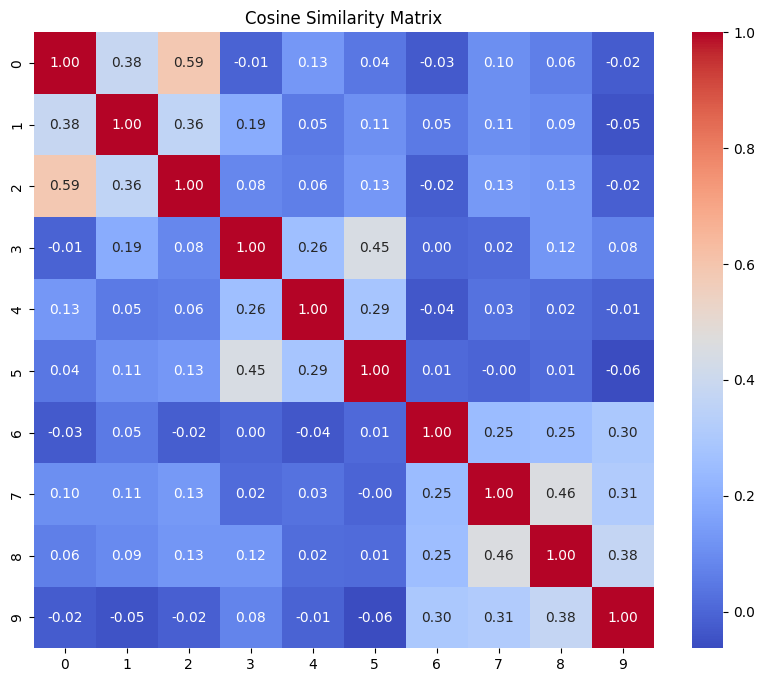

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Sentence: The team won the cricket match by 5 wickets
Similarity Score: 0.7185

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682



In [3]:
import json
import os

notebook_path = "embeddings_demo.ipynb"
nb = None # Initialize nb to None

try:
    with open(notebook_path, "r") as f:
        nb = json.load(f)
except FileNotFoundError:
    print(f"Error: The file '{notebook_path}' was not found. Please ensure it exists in the current directory.")
    print("If you intended to clean the current notebook, please save it as 'embeddings_demo.ipynb' first.")

if nb is not None: # Only proceed if the notebook was successfully loaded
    # Remove only widget metadata (NOT outputs)
    if "metadata" in nb and "widgets" in nb["metadata"]:
        del nb["metadata"]["widgets"]

    with open("embeddings_demo_clean.ipynb", "w") as f:
        json.dump(nb, f)

    print(f"Successfully cleaned and saved to 'embeddings_demo_clean.ipynb'")

Successfully cleaned and saved to 'embeddings_demo_clean.ipynb'
